# HW2 Part 2.3: Analyzing Data Directly from S3

Load the hourly Wikipedia event data **directly from `s3://dsan6000-me878`** using `pd.read_parquet()` with S3 URIs, then plot hourly event counts with `seaborn`.

> **Note:** this notebook never touches the local `data` subfolder. Every read is an `s3://` URI, so this code would run unchanged on any machine in a cluster.

In [1]:
import boto3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

NETID = "me878"
BUCKET = f"dsan6000-{NETID}"
PREFIX = "wikipedia-hourly"
IMAGES_DIR = "images"

sns.set_theme(style="whitegrid")
s3 = boto3.client("s3")

## List the hourly files in my own S3 bucket

In [2]:
paginator = s3.get_paginator("list_objects_v2")
keys = sorted(
    o["Key"]
    for p in paginator.paginate(Bucket=BUCKET, Prefix=PREFIX)
    for o in p.get("Contents", [])
    if o["Key"].endswith(".parquet")
)
print(f"{len(keys)} files in s3://{BUCKET}/{PREFIX}/")
keys[:3]

24 files in s3://dsan6000-me878/wikipedia-hourly/


['wikipedia-hourly/20260901_040000.parquet',
 'wikipedia-hourly/20260901_050000.parquet',
 'wikipedia-hourly/20260901_060000.parquet']

## Read each hourly file directly from S3 and combine

`pd.read_parquet()` accepts an S3 URI directly. No credentials are passed explicitly: Boto3 picks up the EC2 instance's IAM role automatically, which is what allows access to this **private** bucket.

In [3]:
hourly_dfs = []
for key in keys:
    uri = f"s3://{BUCKET}/{key}"
    hourly_dfs.append(pd.read_parquet(uri))
    print(f"read {uri}")

df = pd.concat(hourly_dfs, ignore_index=True)
df["hour"] = pd.to_datetime(df["file_ts_str"], format="%Y%m%d_%H%M%S")
print(f"\ncombined shape: {df.shape}")
df[["hour", "type", "title", "user"]].head()

read s3://dsan6000-me878/wikipedia-hourly/20260901_040000.parquet


read s3://dsan6000-me878/wikipedia-hourly/20260901_050000.parquet


read s3://dsan6000-me878/wikipedia-hourly/20260901_060000.parquet


read s3://dsan6000-me878/wikipedia-hourly/20260901_070000.parquet


read s3://dsan6000-me878/wikipedia-hourly/20260901_080000.parquet


...

read s3://dsan6000-me878/wikipedia-hourly/20260902_000000.parquet


read s3://dsan6000-me878/wikipedia-hourly/20260902_010000.parquet


read s3://dsan6000-me878/wikipedia-hourly/20260902_020000.parquet


read s3://dsan6000-me878/wikipedia-hourly/20260902_030000.parquet

combined shape: (119708, 30)


,hour,type,title,user
0,2026-09-01 04:00:00,edit,Jake O'Donnell,Leeapp
1,2026-09-01 04:00:00,edit,Beveridge Award,Birjeta01
2,2026-09-01 04:00:00,edit,1920 United States presidential election in Wa...,WMSR
3,2026-09-01 04:00:00,edit,1987 Aegean crisis,A.Cython
4,2026-09-01 04:00:00,edit,Marvin Schwäbe,~2026-47482-25


## Plot 1: Total events per hour

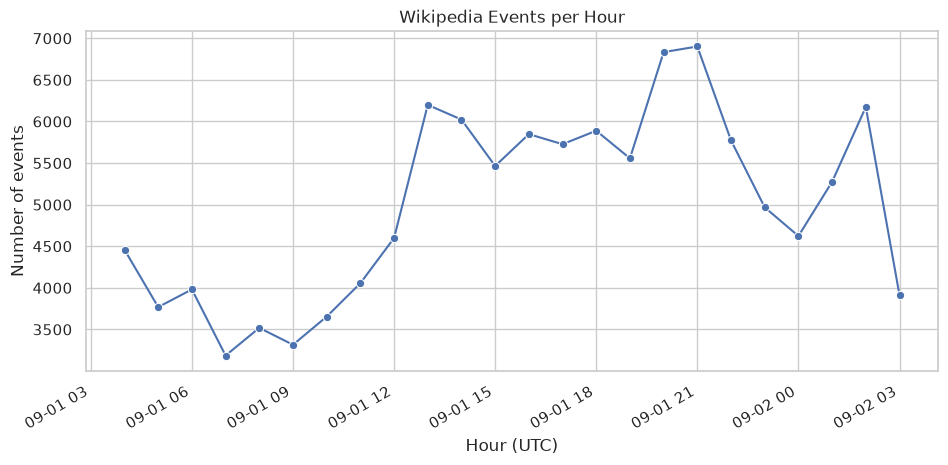

In [4]:
hourly_counts = df.groupby("hour").size().reset_index(name="events")

fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(data=hourly_counts, x="hour", y="events", marker="o", ax=ax)
ax.set_title("Wikipedia Events per Hour")
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("Number of events")
fig.autofmt_xdate()

fig.savefig(f"{IMAGES_DIR}/hourly-events.png", dpi=150, bbox_inches="tight")
fig.savefig(f"{IMAGES_DIR}/hourly-events.svg", bbox_inches="tight")
plt.show()

## Plot 2: Hourly event counts by type

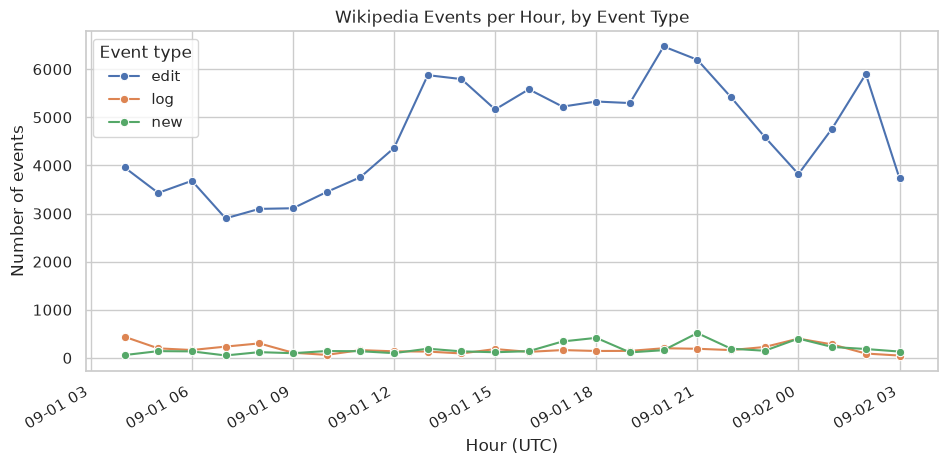

In [5]:
type_counts = df.groupby(["hour", "type"]).size().reset_index(name="events")

fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(data=type_counts, x="hour", y="events", hue="type", marker="o", ax=ax)
ax.set_title("Wikipedia Events per Hour, by Event Type")
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("Number of events")
ax.legend(title="Event type")
fig.autofmt_xdate()

fig.savefig(f"{IMAGES_DIR}/events-by-type.png", dpi=150, bbox_inches="tight")
fig.savefig(f"{IMAGES_DIR}/events-by-type.svg", bbox_inches="tight")
plt.show()